In [ ]:
import numpy as np
import pandas as pd
import uwb_dataset
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

data = uwb_dataset.import_from_files()  # numpy array

# column names based on CSV format
base_cols = [
    "NLOS","RANGE","FP_IDX","FP_AMP1","FP_AMP2","FP_AMP3",
    "STDEV_NOISE","CIR_PWR","MAX_NOISE","RXPACC","CH",
    "FRAME_LEN","PREAM_LEN","BITRATE","PRFR"
]
cir_cols = [f"CIR{i}" for i in range(1016)]
cols = base_cols + cir_cols

df = pd.DataFrame(data, columns=cols)
df.head()

../dataset/uwb_dataset_part2.csv
../dataset/uwb_dataset_part3.csv
../dataset/uwb_dataset_part1.csv
../dataset/uwb_dataset_part4.csv
../dataset/uwb_dataset_part5.csv
../dataset/uwb_dataset_part7.csv
../dataset/uwb_dataset_part6.csv


,NLOS,RANGE,FP_IDX,FP_AMP1,FP_AMP2,FP_AMP3,STDEV_NOISE,CIR_PWR,MAX_NOISE,RXPACC,...,CIR1006,CIR1007,CIR1008,CIR1009,CIR1010,CIR1011,CIR1012,CIR1013,CIR1014,CIR1015
0,1.0,6.18,749.0,4889.0,13876.0,10464.0,240.0,9048.0,3668.0,1024.0,...,0.798828,0.916016,0.574219,0.270508,0.709961,0.358398,0.784180,0.799805,0.456055,0.75
1,1.0,4.54,741.0,2474.0,2002.0,1593.0,68.0,6514.0,1031.0,1024.0,...,0.282227,0.222656,0.104492,0.475586,0.479492,0.394531,0.326172,0.205078,0.099609,0.00
2,1.0,4.39,744.0,1934.0,2615.0,4114.0,52.0,2880.0,796.0,1024.0,...,0.120117,0.274414,0.471680,0.094727,0.265625,0.071289,0.122070,0.165039,0.177734,0.00
3,1.0,1.27,748.0,16031.0,17712.0,10420.0,64.0,12855.0,1529.0,323.0,...,0.523220,0.427245,0.678019,0.291022,0.696594,0.479876,0.532508,0.860681,0.984520,0.00
4,0.0,1.16,743.0,20070.0,19886.0,15727.0,76.0,11607.0,2022.0,296.0,...,0.293919,0.145270,1.209459,1.040541,0.445946,0.442568,0.344595,0.425676,0.550676,0.00


In [43]:
WINDOW_SIZE = 200
LEAD        = 10  

cir_array  = df[cir_cols].to_numpy()
fp_indices = df["FP_IDX"].to_numpy().astype(int)

windowed = np.zeros((len(df), WINDOW_SIZE))

for i in range(len(df)):
    fp_idx = fp_indices[i]
    start  = max(0, fp_idx - LEAD)
    end    = min(1016, start + WINDOW_SIZE)
    actual_size               = end - start
    windowed[i, :actual_size] = cir_array[i, start:end]

df          = df.drop(columns=cir_cols)
cir_cols    = [f"CIR_{i}" for i in range(WINDOW_SIZE)]  
windowed_df = pd.DataFrame(windowed, columns=cir_cols, index=df.index)
df          = pd.concat([df, windowed_df], axis=1)

# Verify
print(f"Windowed array shape: {windowed.shape}")
print(f"New df shape: {df.shape}")
print(f"All zero rows: {(windowed == 0).all(axis=1).sum()}")


Windowed array shape: (42000, 200)
New df shape: (42000, 215)
All zero rows: 0


Basic Cleaning/Validation

In [44]:
print("Missing values:", df.isna().sum().sum())
print("Duplicates:", df.duplicated().sum())

#drop duplicates if any
df = df.drop_duplicates()

Missing values: 0
Duplicates: 0


feature engineering

In [45]:
# FP “power” aggregate
df["FP_POWER"] = (df["FP_AMP1"]**2 + df["FP_AMP2"]**2 + df["FP_AMP3"]**2)

# Simple CIR summary stats (fast, useful)
cir = df[cir_cols].to_numpy()
df["CIR_MEAN"] = cir.mean(axis=1)
df["CIR_MAX"]  = cir.max(axis=1)
df["CIR_ENERGY"] = (cir**2).mean(axis=1)  # average energy

df[["FP_POWER","CIR_MEAN","CIR_MAX","CIR_ENERGY"]].head()

df

,NLOS,RANGE,FP_IDX,FP_AMP1,FP_AMP2,FP_AMP3,STDEV_NOISE,CIR_PWR,MAX_NOISE,RXPACC,...,CIR_194,CIR_195,CIR_196,CIR_197,CIR_198,CIR_199,FP_POWER,CIR_MEAN,CIR_MAX,CIR_ENERGY
0,1.0,6.18,749.0,4889.0,13876.0,10464.0,240.0,9048.0,3668.0,1024.0,...,0.669922,0.349609,1.093750,0.911133,0.239258,0.650391,3.259410e+08,1.328721,18.063477,7.179700
1,1.0,4.54,741.0,2474.0,2002.0,1593.0,68.0,6514.0,1031.0,1024.0,...,0.172852,0.139648,0.234375,0.185547,0.274414,0.304688,1.266633e+07,0.956118,13.740234,4.419092
2,1.0,4.39,744.0,1934.0,2615.0,4114.0,52.0,2880.0,796.0,1024.0,...,0.497070,0.126953,0.444336,0.174805,0.280273,0.106445,2.750358e+07,0.823608,7.645508,2.060393
3,1.0,1.27,748.0,16031.0,17712.0,10420.0,64.0,12855.0,1529.0,323.0,...,0.832817,0.600619,0.569659,0.563467,1.030960,0.693498,6.792843e+08,2.775217,65.857585,86.415936
4,0.0,1.16,743.0,20070.0,19886.0,15727.0,76.0,11607.0,2022.0,296.0,...,0.780405,0.817568,0.385135,0.847973,1.060811,0.513514,1.045596e+09,3.797382,71.388514,105.011061
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41995,0.0,4.09,745.0,1106.0,6951.0,6283.0,88.0,10076.0,1856.0,340.0,...,0.841176,0.791176,0.285294,0.755882,1.429412,0.811765,8.901573e+07,3.989191,49.488235,62.791435
41996,0.0,2.18,744.0,14870.0,13482.0,8864.0,44.0,12604.0,781.0,416.0,...,0.110577,0.627404,0.382212,0.225962,0.298077,0.127404,4.814517e+08,2.857680,48.288462,51.167367
41997,0.0,1.25,748.0,18329.0,17722.0,10731.0,60.0,10192.0,1600.0,270.0,...,0.092593,0.351852,0.359259,0.688889,0.911111,0.470370,7.651759e+08,3.634796,69.644444,98.328866
41998,0.0,3.17,747.0,3654.0,18470.0,17737.0,64.0,12018.0,967.0,789.0,...,0.519645,0.253485,0.362484,0.205323,0.389100,0.329531,6.690938e+08,1.503035,23.038023,13.341668


Splitting of data into training and test set (80 : 20)

In [46]:
y = df["NLOS"].astype(int).to_numpy()

non_cir_features = [
    "RANGE","FP_IDX","FP_AMP1","FP_AMP2","FP_AMP3",
    "STDEV_NOISE","CIR_PWR","MAX_NOISE","RXPACC","CH",
    "FRAME_LEN","PREAM_LEN","BITRATE","PRFR",
    "FP_POWER","CIR_MEAN","CIR_MAX","CIR_ENERGY"
]

X_non_cir = df[non_cir_features].to_numpy()   # (42000, 18)
X_cir     = df[cir_cols].to_numpy()            # (42000, 200)
X_raw     = np.hstack([X_non_cir, X_cir])      # (42000, 218)

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train_raw.shape}")   # (33600, 218)
print(f"Test:  {X_test_raw.shape}")    # (8400, 218)

Train: (33600, 218)
Test:  (8400, 218)


Feature Importance Ranking (model-agnostic)

/var/folders/z2/hkp7bywx4s55cf4t53l831x40000gn/T/ipykernel_71326/3059752484.py:18: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  abs(spearmanr(X_fi[:, i], y_fi).statistic)


Rank  Feature               MI Score    Spearman |r|   RF Importance
1     CIR_ENERGY              0.3386          0.7255          0.2458
2     CIR_MAX                 0.3286          0.7117          0.1933
3     RXPACC                  0.3225          0.7049          0.1199
4     CIR_MEAN                0.3073          0.7027          0.0960
5     FP_POWER                0.1881          0.5584          0.0621
6     CIR_PWR                 0.1644          0.4212          0.0339
7     FP_AMP3                 0.1551          0.5065          0.0482
8     FP_AMP2                 0.1481          0.5104          0.0278
9     MAX_NOISE               0.1439          0.1775          0.0312
10    RANGE                   0.1394          0.4449          0.0984
11    FP_AMP1                 0.1149          0.4509          0.0176
12    FP_IDX                  0.0964          0.3417          0.0051
13    STDEV_NOISE             0.0900          0.1916          0.0195
14    PREAM_LEN               0.02

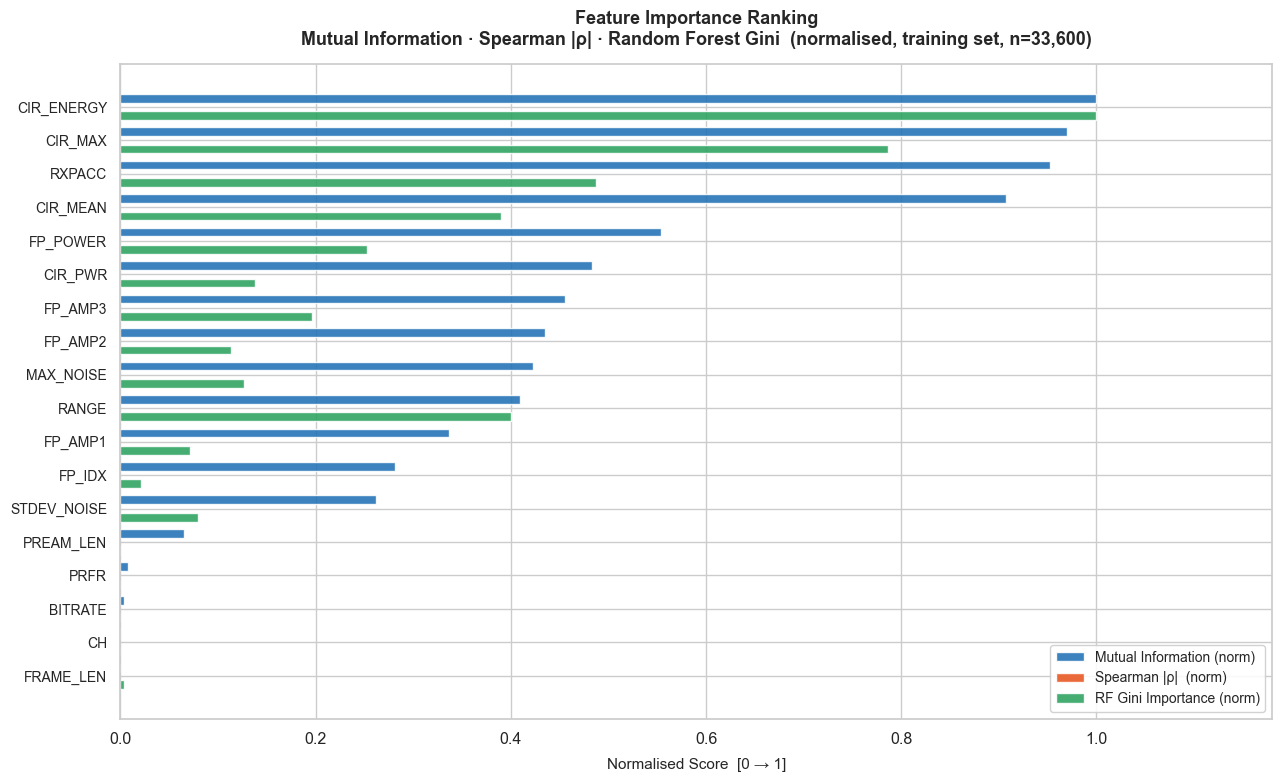

In [54]:

from sklearn.feature_selection import mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import seaborn as sns

# Training set only — never touch test data during preprocessing decisions
X_fi = X_train_raw[:, :18]   # (33600, 18)
y_fi = y_train                # (33600,)

# ── 1. Mutual Information ──────────────────────────────────────────────────────
# Model-agnostic; captures non-linear dependencies between features and target
mi_scores = mutual_info_classif(X_fi, y_fi, random_state=42, n_neighbors=5)

# ── 2. Spearman |ρ| ────────────────────────────────────────────────────────────
# Captures monotonic relationships — scale-invariant cross-check
spearman_r = np.array([
    abs(spearmanr(X_fi[:, i], y_fi).statistic)
    for i in range(X_fi.shape[1])
])

# ── 3. Random Forest Gini Importance ──────────────────────────────────────────
# Shallow forest — purpose is ranking only, NOT final model selection
rf = RandomForestClassifier(n_estimators=200, max_depth=10, n_jobs=-1, random_state=42)
rf.fit(X_fi, y_fi)
rf_importance = rf.feature_importances_

# ── 4. Normalise all three to [0, 1] for fair visual comparison ───────────────
def norm(arr):
    return (arr - arr.min()) / (arr.max() - arr.min())

# ── 5. Ranked DataFrame (primary sort: MI Score) ──────────────────────────────
fi_df = (
    pd.DataFrame({
        "Feature"        : non_cir_features,
        "MI Score"       : mi_scores,
        "Spearman |r|"   : spearman_r,
        "RF Importance"  : rf_importance,
        "MI (norm)"      : norm(mi_scores),
        "Spearman (norm)": norm(spearman_r),
        "RF (norm)"      : norm(rf_importance),
    })
    .sort_values("MI Score", ascending=False)
    .reset_index(drop=True)
)
fi_df.index += 1  # 1-based rank

# ── 6. Print ranked table ─────────────────────────────────────────────────────
print("=" * 74)
print(f"{'Rank':<6}{'Feature':<18}{'MI Score':>12}{'Spearman |r|':>16}{'RF Importance':>16}")
print("=" * 74)
for rank, row in fi_df.iterrows():
    print(f"{rank:<6}{row['Feature']:<18}{row['MI Score']:>12.4f}"
          f"{row['Spearman |r|']:>16.4f}{row['RF Importance']:>16.4f}")
print("=" * 74)

# ── 7. Grouped bar chart — all three metrics normalised to [0, 1] ─────────────
sns.set_theme(style="whitegrid", font_scale=1.05)
fig, ax = plt.subplots(figsize=(13, 8))

features_sorted = fi_df["Feature"].tolist()[::-1]
mi_norm  = fi_df["MI (norm)"].tolist()[::-1]
sp_norm  = fi_df["Spearman (norm)"].tolist()[::-1]
rf_norm  = fi_df["RF (norm)"].tolist()[::-1]

y_pos  = np.arange(len(fi_df))
h      = 0.26  # bar height

ax.barh(y_pos + h,  mi_norm, h, color="#2171B5", alpha=0.88, label="Mutual Information (norm)")
ax.barh(y_pos,      sp_norm, h, color="#E8541E", alpha=0.88, label="Spearman |ρ|  (norm)")
ax.barh(y_pos - h,  rf_norm, h, color="#2CA25F", alpha=0.88, label="RF Gini Importance (norm)")

ax.set_yticks(y_pos)
ax.set_yticklabels(features_sorted, fontsize=10)
ax.set_xlabel("Normalised Score  [0 → 1]", fontsize=11, labelpad=8)
ax.set_xlim(0, 1.18)
ax.set_title(
    "Feature Importance Ranking\n"
    "Mutual Information · Spearman |ρ| · Random Forest Gini  "
    f"(normalised, training set, n={len(X_fi):,})",
    fontsize=13, fontweight="bold", pad=14,
)
ax.legend(loc="lower right", framealpha=0.88, fontsize=10)

plt.tight_layout()
plt.show()


PCA for CIR component of training and test set

In [55]:
from sklearn.compose import ColumnTransformer

drop_features = ["FRAME_LEN", "CH", "BITRATE", "PRFR"] 

selected_features = [f for f in non_cir_features if f not in drop_features]

X_non_cir = df[selected_features].to_numpy()
X_raw     = np.hstack([X_non_cir, X_cir])

n = len(selected_features)
non_cir_idx = list(range(n))                          # auto-adjusts
cir_idx     = list(range(n, n + WINDOW_SIZE))

preprocessor = ColumnTransformer([
    ('non_cir', StandardScaler(), non_cir_idx),
    ('cir', Pipeline([
        ('scaler', StandardScaler()),
        ('pca',    PCA(n_components=86, random_state=42))
    ]), cir_idx)
])

X_train = preprocessor.fit_transform(X_train_raw)  
X_test  = preprocessor.transform(X_test_raw)         

print(f"X_train: {X_train.shape}")  
print(f"X_test:  {X_test.shape}")    
print("Explained variance:", preprocessor.named_transformers_['cir']['pca'].explained_variance_ratio_.sum())

X_train: (33600, 100)
X_test:  (8400, 100)
Explained variance: 0.8102404385400414
